# Mock systematics demo

This notebook contains the main functionality for P(k, mu) recovery on Halfdome lightcones  (and periodic box FastPM) with clean, stellar, and dust systematic variants.

In [1]:
import numpy as np

from pipeline import recommended_base_kwargs, build_mock_variant_specs, run_variant_collection, save_experiment_result
from nonunif_binning import *
from contamination import *
from desi_mocks import *
from plotting_fns import *
from pscalc import *
from contamination import *
from dust import *
from utils import *

np.set_printoptions(precision=4, suppress=True)


In [2]:
''' Load SFD extinction map for reference '''

import os
os.environ["DUSTMAPS_DATA_DIR"] = "/pscratch/sd/r/rmfeder/desi_sys"

from dustmaps.config import config
from dustmaps.sfd import SFDQuery
import dustmaps.sfd
ebv_sfd = dustmaps.sfd.fetch()  # downloads and caches the map



Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.
Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.


Using dustmaps data_dir: /pscratch/sd/r/rmfeder/desi_sys


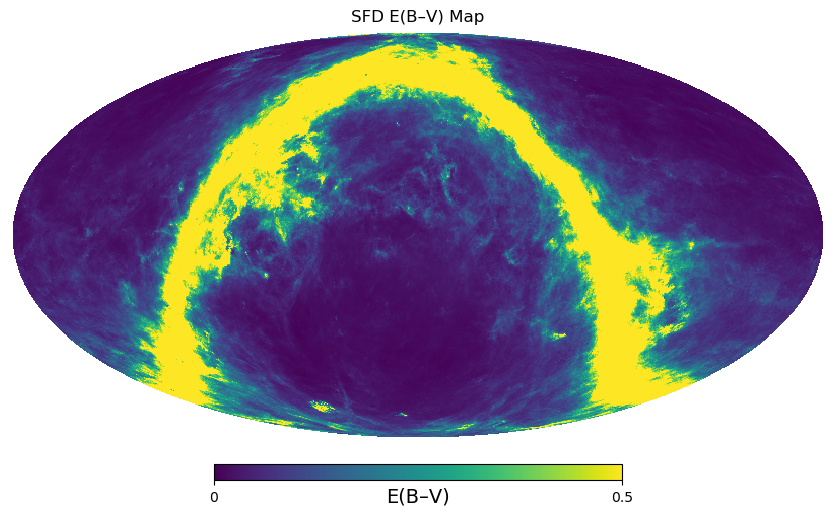

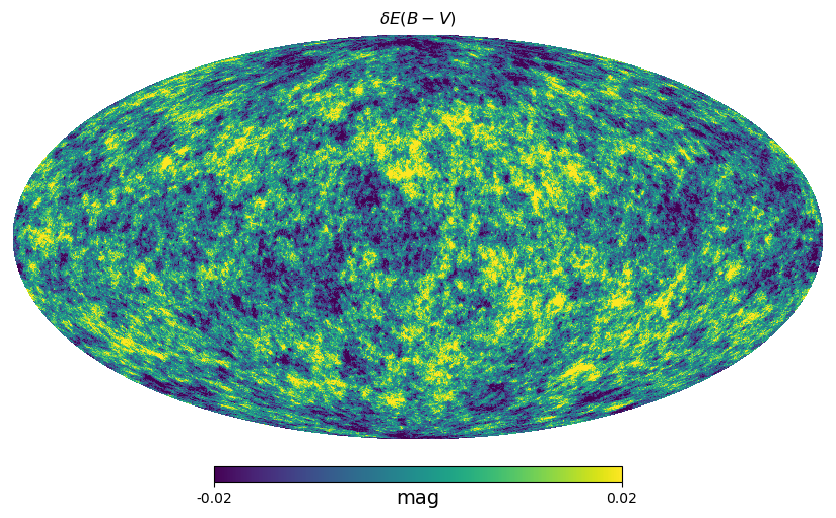

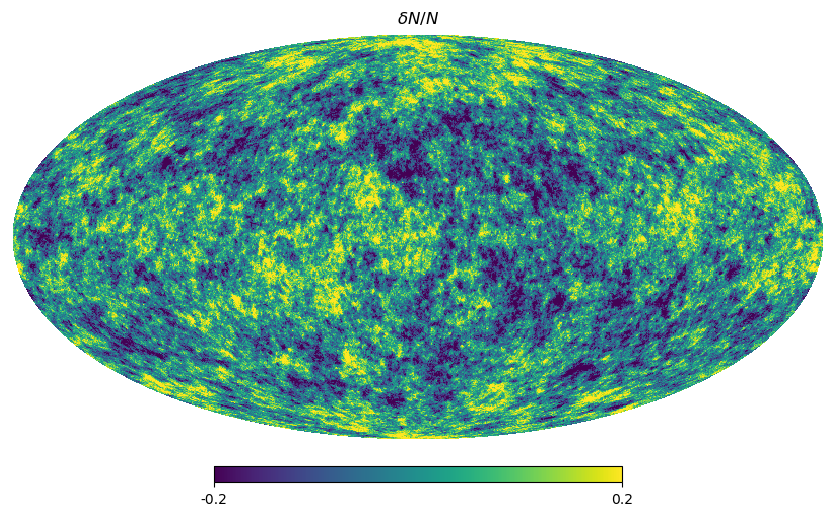

In [3]:
''' 
This cell shows how we generate a "dust extinction error" map, which is then translated into a modulation of number density dN/N using an assumed (tracer-dependent) response. 

The dust extinction error is assumed to have an angular power spectrum matching that of the SFD map, but normalized to a user-inputted standard deviation ("std"). 
The extinction error map is generated as a Gaussian random field, i.e., independent of the phases of the SFD map itself.

Operationally, this dN/N maps is used to modulate the FKP weights rather than trying to resample the data catalog.

In the mock recovery tests, this functionality is built into the pipeline, but I'm showing it here explicitly for clarity.

'''

# get the SFD power spectrum
ebv_map, cl_sfd = gen_sfd_hp()

# plot it
hp.mollview(ebv_map, title='SFD E(B–V) Map', unit='E(B–V)', min=0.0, max=0.5)

# std = 0.01 corresponds to a pixel-wise standard deviation of +/- 10 mmag
delta_ebv = gen_delta_ebv_map_uncorr(cl_sfd, std=0.01)

hp.mollview(delta_ebv, title='$\\delta E(B-V)$', unit='mag', min=-0.02, max=0.02)

''' 
Parameter alpha defines the response relating extinction errors to number density, i.e., dN/N = alpha * d(E(B-V))/E(B-V).
The parameter alpha is negative because an overestimated E(B-V) leads to an underselection of galaxies. 
For ELGs, alpha = -10 (i.e., 0.01 mag error corresponds to +/- 10% in number density), while for LRG/QSO it is estimated to be alpha ~ -1 to -2.
'''

alpha = -10. 
delta_n_over_n_uncorr = gen_dn_n_map(grf_map=delta_ebv, alpha=alpha)
    
hp.mollview(delta_n_over_n_uncorr, title='$\\delta N/N$', unit=None, min=-0.2, max=0.2)

Generating notional stellar catalog with N_gal=10000000.0, frac=0.01, nside=64...
Generated 100044 stars.


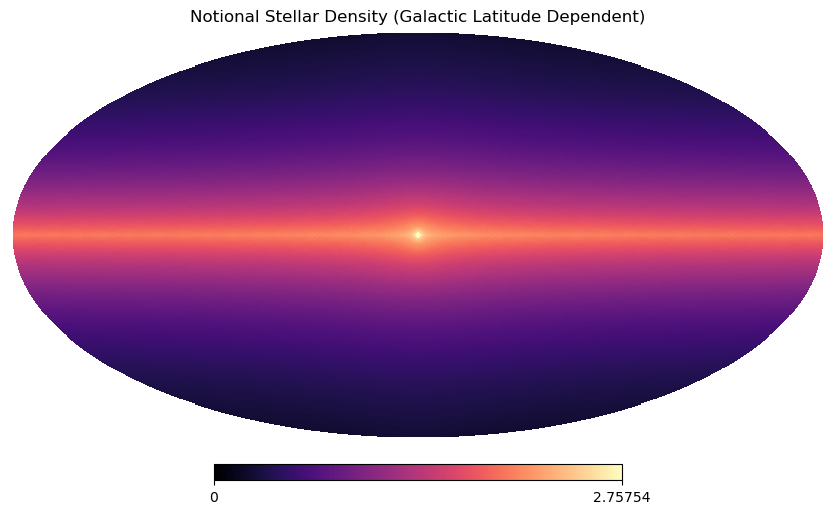

In [4]:
''' Simple model for Milky Way stellar distribution, can use this or Gaia stellar density map to inject stars '''


N_galaxies = 1e7
fraction_stars = 0.01
nside_map = 64
print(f"Generating notional stellar catalog with N_gal={N_galaxies}, frac={fraction_stars}, nside={nside_map}...")
ra_stars, dec_stars, notional_map = simple_halo_thick_disk_stellar_density(
    N_gal=N_galaxies,
    frac=fraction_stars,
    nside=nside_map,
    halo_power_law_exp=0.3,    # Adjust this: higher means faster drop-off from GC
    thick_disk_amplitude=1.8, # Increase relative thick disk contribution
    thick_disk_b_scale=25.0,   # Make the thick disk slightly more extended
    seed=45
)

print(f"Generated {len(ra_stars)} stars.")

# Plot the notional stellar density map
hp.mollview(notional_map, title='Notional Stellar Density (Galactic Latitude Dependent)', cmap='magma', min=0)
plt.show()

In [5]:
# for a delta function transverse systematic, the ideal non-uniform binning is determined by zero crossings of Legendre function

# Parameters
ell_max = 16
n_clean_bins = 8

bins = compute_null_bins(ell_max, n_clean_bins)

print("Mu bin edges:")
print(np.round(bins, 4))

Mu bin edges:
[0.     0.1111 0.2732 0.4445 0.5864 0.7322 0.8302 0.9274 0.9713 1.    ]


In [6]:
''' 
The basic configuration can be called with recommended_base_kwargs. Some relevant parameters:

- "dust_alpha = -10.0" assumes ELG-like number density response to dust extinction error (), to switch to LRG-like response one can update the base kwargs:

    base_kwargs.update({
        "dust_alpha": -1.5,   # e.g. LRG-like sensitivity
    }).

- "use_gaia = False" means the stellar contamination follows the simple geometric model included above, rather than the Gaia stellar density directly.

- mu_binning_strategy = 'nonuniform' defaults to the non-uniform mu binning for a delta function transverse systematic, but one can switch to fixed mu bins if desired, e.g.,

    base_kwargs.update({
        'mu_binning_strategy': 'uniform',
        'mu_min': 0.0,
        'mu_max': 1.0,
        'nwedge': 7,   # gives 6 uniform mu bins
    })

'''


mock_type = "quijote" # misnomer, FastPM cubic mocks
# mock_type = "halfdome" # HalfDome lightcone

base_kwargs = recommended_base_kwargs(mock_type=mock_type)

base_kwargs


{'mock_type': 'quijote',
 'with_rsd': False,
 'contamination_mode': 'none',
 'frac_stellar_contam': 0.1,
 'use_gaia': False,
 'sfd_std': 0.01,
 'dust_alpha': -10.0,
 'redshift_sel': True,
 'zmin': 0.4,
 'zmax': 1.0,
 'replicate': False,
 'rep_fac': 1,
 'ds_fac': 5,
 'randomize': False,
 'n_sample': 20000000,
 'k_min': 0.002,
 'k_max': 0.2,
 'delta_k': 0.01,
 'mu_binning_strategy': 'nonuniform',
 'n_clean_bins': 8,
 'ells': (0, 2, 4, 6, 8, 10, 12, 14, 16),
 'nmesh': 512,
 'seed': 42,
 'quijote_geometry': 'full_cube'}

In [10]:
''' 

This sets the baseline configuration and variants where systematics are injected to modify the observed galaxy density field. 

All options from contamination_modes, with_rsd_options, stellar_fracs and sfd_stds are enumerated. So if one has

contamination_modes=('none', 'stellar', 'dust')
with_rsd_options=('False', 'True'),
stellar_fracs=(0.01,),
sfd_stds=(0.01,),

there would be six variants.

'''

save_dir = 'data/plk/' # specify the base directory you want the results saved to

base_kwargs.update({
    'save_dir': save_dir,
})

specs = build_mock_variant_specs(
    mock_type=mock_type,
    contamination_modes=('none', 'stellar', 'dust'),
    with_rsd_options=('False',), # make sure there is a comma following the values, otherwise the enumeration is messed up
    stellar_fracs=(0.1,),
    sfd_stds=(0.01,),
    base_kwargs=base_kwargs,
)

print(str(len(specs))+' variants..')

for variant in range(len(specs)):

    print('Variant '+str(variant))
    print(specs[variant])


3 variants..
Variant 0
ExperimentSpec(mock_type='quijote', with_rsd=False, contamination_mode='none', frac_stellar_contam=0.1, use_gaia=False, sfd_std=0.01, dust_alpha=-10.0, redshift_sel=False, zmin=0.4, zmax=1.0, replicate=False, rep_fac=1, ds_fac=5, randomize=False, n_sample=20000000, k_min=0.002, k_max=0.2, delta_k=0.01, mu_min=0.0, mu_max=1.0, nwedge=6, mu_wedges=None, mu_binning_strategy='nonuniform', n_clean_bins=8, ells=(0, 2, 4, 6, 8, 10, 12, 14, 16), nmesh=512, boxsize=1000.0, n_random_factor=5, seed=42, save_dir='data/plk', output_name=None, plot=False, nplot=0, quijote_basedir='/global/cfs/cdirs/desi/users/rmfeder/quijote/fiducial/systematics/', halfdome_basedir='/global/cfs/cdirs/cmb/gsharing/halfdome/full_res/halos/', quijote_geometry='full_cube')
Variant 1
ExperimentSpec(mock_type='quijote', with_rsd=False, contamination_mode='stellar', frac_stellar_contam=0.1, use_gaia=False, sfd_std=0.01, dust_alpha=-10.0, redshift_sel=False, zmin=0.4, zmax=1.0, replicate=False, rep_fa

In [12]:

results = run_variant_collection(specs, nmock=1)
output_paths = {label: save_experiment_result(result) for label, result in results.items()}

summary = []
for label, result in results.items():
    summary.append({
        'label': label,
        'pkmu_shape': result.all_pkmu.shape,
        'plk_shape': result.all_plk.shape,
    })

summary

Mock directory is  /global/cfs/cdirs/desi/survey/catalogs/Y3/mocks/SecondGenMocks/AbacusSummit_v4_1/
fpath is  /global/cfs/cdirs/desi/users/rmfeder/quijote/fiducial/systematics/0/numpy/gal_Position.npy
boxdims: [999.9996, 999.99945, 999.9996]
Center offset [Mpc/h]: 500.0
Center offset [Mpc/h]: 500.0
Mock directory is  /global/cfs/cdirs/desi/survey/catalogs/Y3/mocks/SecondGenMocks/AbacusSummit_v4_1/
fpath is  /global/cfs/cdirs/desi/users/rmfeder/quijote/fiducial/systematics/0/numpy/gal_Position.npy
boxdims: [999.9996, 999.99945, 999.9996]
Center offset [Mpc/h]: 500.0
Center offset [Mpc/h]: 500.0
Mock directory is  /global/cfs/cdirs/desi/survey/catalogs/Y3/mocks/SecondGenMocks/AbacusSummit_v4_1/
fpath is  /global/cfs/cdirs/desi/users/rmfeder/quijote/fiducial/systematics/0/numpy/gal_Position.npy
boxdims: [999.9996, 999.99945, 999.9996]
Center offset [Mpc/h]: 500.0
Using dustmaps data_dir: /pscratch/sd/r/rmfeder/desi_sys
Center offset [Mpc/h]: 500.0


[{'label': 'quijote_full_cube_noRSD_none_ds5_nonunifmu8_lmax16',
  'pkmu_shape': (1, 20, 9),
  'plk_shape': (1, 9, 20)},
 {'label': 'quijote_full_cube_noRSD_stellar_star0p1_notional_ds5_nonunifmu8_lmax16',
  'pkmu_shape': (1, 20, 9),
  'plk_shape': (1, 9, 20)},
 {'label': 'quijote_full_cube_noRSD_dust_dust0p01_am10_ds5_nonunifmu8_lmax16',
  'pkmu_shape': (1, 20, 9),
  'plk_shape': (1, 9, 20)}]

mu wedges: [0.     0.1111 0.2732 0.4445 0.5864 0.7322 0.8302 0.9274 0.9713 1.    ]
[0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


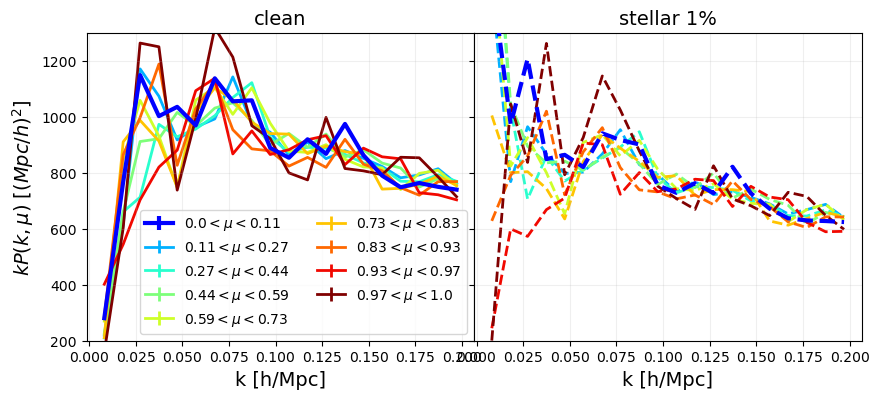

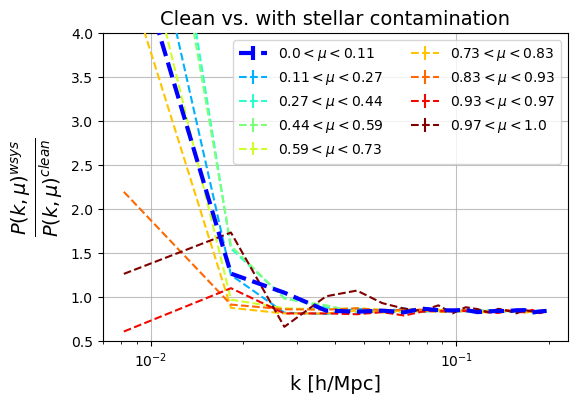

mu wedges: [0.     0.1111 0.2732 0.4445 0.5864 0.7322 0.8302 0.9274 0.9713 1.    ]
[0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


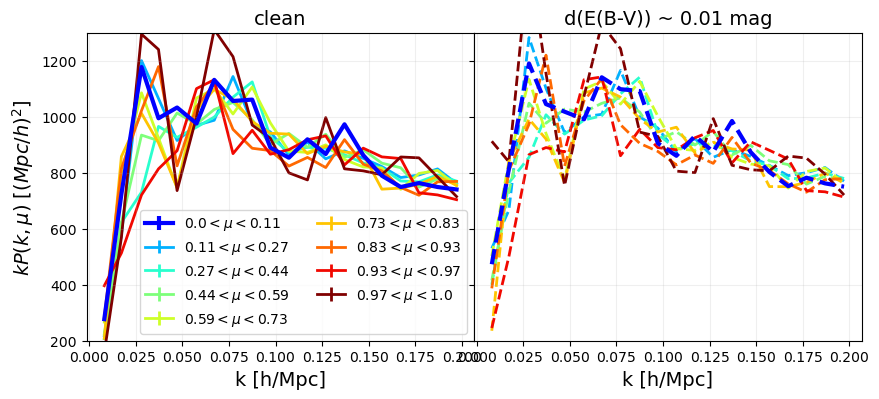

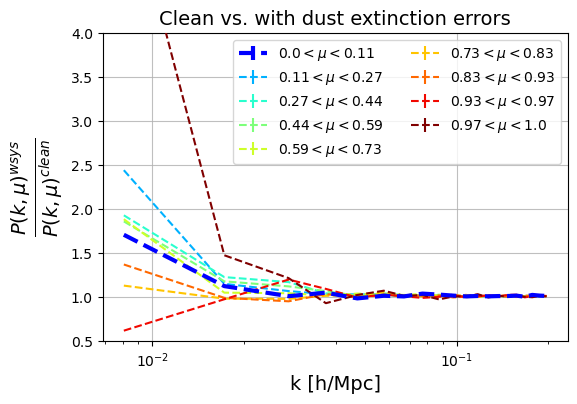

(<Figure size 1000x400 with 2 Axes>, <Figure size 600x400 with 1 Axes>)

In [17]:
clean_label = next(label for label in results if '_none_' in label)
stellar_label = next(label for label in results if '_stellar_' in label)
dust_label = next(label for label in results if '_dust_' in label)

fpath_clean = output_paths[clean_label]
fpath_stellar = output_paths[stellar_label]
fpath_dust = output_paths[dust_label]

fig_ps, fig_ratio = compare_pkmu_wsys(
    fpath_clean,
    fpath_wsys=fpath_stellar,
    title='Clean vs. with stellar contamination',
    cleanlab='clean',
    syslab='stellar 1%',
    ylim_ps=[200, 1300],
    ylim_ratio=[0.5, 4.0],
    figsize_ratio=(6, 4),
    
)

fig_ps, fig_ratio = compare_pkmu_wsys(
    fpath_clean,
    fpath_wsys=fpath_dust,
    title='Clean vs. with dust extinction errors',
    cleanlab='clean',
    syslab='d(E(B-V)) ~ '+str(specs[2].sfd_std)+' mag',
    ylim_ps=[200, 1300],
    ylim_ratio=[0.5, 4.0],
    figsize_ratio=(6, 4),
    
)


fig_ps, fig_ratio